# TabPFN Missing Value Imputation vs Classical Anomaly Detection Methods

실험 가설: **TabPFN imputation 성능이 낮을수록 anomaly일 가능성이 높다**

- TabPFN missing value reconstruction error를 anomaly score로 사용
- Isolation Forest, One-Class SVM, Local Outlier Factor 등과 성능 비교
- AUC, Accuracy 메트릭으로 비교

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

# TabPFN imports
try:
    from tabpfn import TabPFNClassifier
except ImportError:
    print("TabPFN not available, using fallback")
    TabPFNClassifier = None

# Load dataset
from utils.tabular_loader import ADBenchDataLoader

plt.style.use('default')
sns.set_palette("husl")

## 1. 데이터 로드 및 준비

In [11]:

import os, re
import numpy as np

# 데이터 로더 초기화
data_loader = ADBenchDataLoader('dataset/Classical', normalize=True)

# ✅ (수정1) 폴더에서 1_~10_로 시작하는 .npz를 자동 수집
root = 'dataset/Classical'
all_files = [f for f in os.listdir(root) if f.endswith('.npz')]

def get_prefix_int(fname):
    m = re.match(r'^(\d+)_', fname)
    return int(m.group(1)) if m else 10**9

# 1~10만, 번호순 정렬
datasets = [f[:-4] for f in sorted(all_files, key=get_prefix_int)  # .npz 제거
            if re.match(r'^([1-9]|10)_', f)]
datasets = datasets[1:2]  # 안전장치

results = {}

print("Loading datasets...")
for dataset_name in datasets:
    try:
        # Load test split for evaluation (기존 로직 유지)
        dataset = data_loader.load_dataset(dataset_name, train=False, test_size=0.3, random_state=42)

        X = dataset.X_split
        y = dataset.y_split  # 0: normal, 1: anomaly

        results[dataset_name] = {
            'X': X,
            'y': y,
            'feature_names': dataset.feature_names
        }

        normal_count = np.sum(y == 0)
        anomaly_count = np.sum(y == 1)
        print(f"{dataset_name}: Total={len(X)}, Normal={normal_count}, Anomaly={anomaly_count}, Features={X.shape[1]}")

    except Exception as e:
        print(f"Error loading {dataset_name}: {e}")

print(f"\nLoaded {len(results)} datasets successfully")


Loading datasets...
2_annthyroid: Total=2160, Normal=2000, Anomaly=160, Features=6

Loaded 1 datasets successfully


## 2. TabPFN Missing Value Imputation 기반 Anomaly Detection
- missing imputation: 전체 데이터 중 랜덤으로 masking하고 재현, 차이가 클수록 이상치
- missing imputation2: 전체 변수 중 랜덤으로 선정된 절반의 변수로 나머지 절반의 변수 값들을 재현. 차이가 클수록 이상치.

In [12]:
import numpy as np
import pandas as pd

def generate_variable_sets(n_features, n_sets=10, ratio=0.5, random_state=42):
    rng = np.random.default_rng(random_state)
    sets = []
    k = max(1, int(n_features * ratio))
    for _ in range(n_sets):
        cols = rng.choice(n_features, size=k, replace=False)
        sets.append(np.sort(cols))
    return sets

def split_features(n_features, random_state=42):
    """Randomly split columns into X (features) and Y (targets) with half-half"""
    rng = np.random.default_rng(random_state)
    perm = rng.permutation(n_features)
    half = n_features // 2 + 1
    X_cols = perm[:half]
    Y_cols = perm[half:]
    print(f"features split into {X_cols} X and {Y_cols} Y")
    return X_cols, Y_cols

def tabpfn_xy_reconstruction_anomaly_scores(
    X,
    n_trials=3,
    n_subsamples=5,          # 여러 번 반복 횟수
    subsample_size=1000,     # 매 반복에서 fit에 쓸 샘플 수
    n_bins=5,
    min_train=5,
    random_state=42
):
    """Anomaly scores using chain-rule joint conditional likelihood (surrogate)."""
    n_samples, n_features = X.shape
    log_scores = np.zeros(n_samples, dtype=float)

    for trial in range(n_trials):
        X_cols, Y_cols = split_features(n_features, random_state=random_state + trial)
        X_feat = X[:, X_cols].copy()

        # fill NaNs in X
        col_means = np.nanmean(X_feat, axis=0)
        nan_pos = np.isnan(X_feat)
        if nan_pos.any():
            X_feat[nan_pos] = np.take(col_means, np.where(nan_pos)[1])

        # random chain order on Y
        rng_chain = np.random.default_rng(random_state + trial)
        chain = rng_chain.permutation(Y_cols)

        trial_log_score = np.zeros(n_samples, dtype=float)

        for t, y_col in enumerate(chain):
            y = X[:, y_col].copy()
            train_mask = ~np.isnan(y)
            train_idx = np.where(train_mask)[0]

            # fallback: train too small
            if train_idx.size < min_train:
                pred_mean = np.full(n_samples, np.nanmean(y))
                valid = ~np.isnan(y)
                err = np.abs(y[valid] - pred_mean[valid])
                trial_log_score[valid] += -err  # 1회분만
                X_feat = np.column_stack([X_feat, pred_mean])
                continue

            y_train = y[train_mask]

            # binning on train only
            y_bin = pd.cut(
                y_train,
                bins=n_bins,
                labels=False,
                duplicates='drop'
            )

            # if bins collapsed or TabPFN unavailable -> simple mean predictor
            if len(np.unique(y_bin)) < 2 or ('TabPFNClassifier' not in globals()) or (TabPFNClassifier is None):
                pred_mean = np.full(n_samples, np.mean(y_train))
                valid = ~np.isnan(y)
                err = np.abs(y[valid] - pred_mean[valid])
                trial_log_score[valid] += -err
                X_feat = np.column_stack([X_feat, pred_mean])
                continue

            # repeated subsample fitting
            preds = []
            valid = ~np.isnan(y)

            # train_mask 내부 좌표계에서 뽑아야 y_bin[sub_pos]가 성립
            m = min(subsample_size, train_idx.size)

            rng_fit = np.random.default_rng(random_state + trial * 1000 + t)
            for r in range(n_subsamples):
                sub_pos = rng_fit.choice(train_idx.size, size=m, replace=False)
                sub_idx = train_idx[sub_pos]

                clf = TabPFNClassifier(device='cpu')
                clf.fit(X_feat[sub_idx], y_bin[sub_pos])

                pb = clf.predict(X_feat)  # (n_samples,)

                y_min, y_max = y_train.min(), y_train.max()
                pred_r = y_min + (pb + 0.5) * (y_max - y_min) / max(1, n_bins)
                preds.append(pred_r)

                # score는 요청대로 "합산"
                err_r = np.abs(y[valid] - pred_r[valid])
                trial_log_score[valid] += -err_r

            # chain-rule imputation은 단일 값 필요 -> 평균 pred를 사용
            pred_mean = np.mean(np.stack(preds, axis=0), axis=0)
            X_feat = np.column_stack([X_feat, pred_mean])

        # 기존 스케일 유지용(체인 길이로 나눔). 합산을 원하면 이 줄은 그대로 두면 "체인 평균"이 되고,
        # "그대로 총합"이 진짜 필요하면 /len(chain) 제거하면 됨.
        log_scores += trial_log_score / len(chain)

    return log_scores / n_trials


## 3. Classical Anomaly Detection Methods

In [13]:
def get_classical_anomaly_scores(X):
    """Get anomaly scores from classical methods"""
    scores = {}
    
    # Standardize data for some methods
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    try:
        # 1. Isolation Forest
        iso_forest = IsolationForest(contamination='auto', random_state=42)
        iso_scores = iso_forest.fit(X).decision_function(X)
        scores['Isolation Forest'] = -iso_scores  # Convert to anomaly scores (higher = more anomalous)
    except Exception as e:
        print(f"Isolation Forest error: {e}")
        scores['Isolation Forest'] = np.zeros(len(X))
    
    try:
        # 2. One-Class SVM
        oc_svm = OneClassSVM(gamma='auto')
        svm_scores = oc_svm.fit(X_scaled).decision_function(X_scaled)
        scores['One-Class SVM'] = -svm_scores
    except Exception as e:
        print(f"One-Class SVM error: {e}")
        scores['One-Class SVM'] = np.zeros(len(X))
    
    try:
        # 3. Local Outlier Factor
        lof = LocalOutlierFactor(novelty=True)
        lof.fit(X_scaled)
        lof_scores = lof.decision_function(X_scaled)
        scores['Local Outlier Factor'] = -lof_scores
    except Exception as e:
        print(f"Local Outlier Factor error: {e}")
        scores['Local Outlier Factor'] = np.zeros(len(X))
    
    try:
        # 4. Elliptic Envelope
        ee = EllipticEnvelope(contamination=0.1, random_state=42)
        ee_scores = ee.fit(X_scaled).decision_function(X_scaled)
        scores['Elliptic Envelope'] = -ee_scores
    except Exception as e:
        print(f"Elliptic Envelope error: {e}")
        scores['Elliptic Envelope'] = np.zeros(len(X))
    
    return scores

## 4. 실험 수행: 모든 방법들 비교

In [ ]:
experiment_results = []
missing_ratios = [0.05, 0.1, 0.15]

print("Starting comprehensive anomaly detection comparison...")

for dataset_name in results.keys():
    print(f"\nProcessing {dataset_name}...")
    
    X = results[dataset_name]['X']
    y_true = results[dataset_name]['y']  # 0: normal, 1: anomaly
    
    # Skip datasets with too few anomalies
    if np.sum(y_true == 1) < 3:
        print(f"  Skipping {dataset_name}: too few anomalies ({np.sum(y_true == 1)})")
        continue
    

    varsets = generate_variable_sets(X.shape[1], n_sets=10)

    for vs_id, X_cols in enumerate(varsets):
        Y_cols = np.setdiff1d(np.arange(X.shape[1]), X_cols)

        # TabPFN
        scores = tabpfn_xy_reconstruction_anomaly_scores(X)
        auc = roc_auc_score(y_true, scores)

        experiment_results.append({
            'dataset': dataset_name,
            'method': 'TabPFN-Imputation2',
            'varset': vs_id,
            'auc': auc
        })

        # Classical baselines on same subset
        # X_sub = X[:, X_cols]
    classical_scores = get_classical_anomaly_scores(X)

    for m, sc in classical_scores.items():
        auc = roc_auc_score(y_true, sc)
        experiment_results.append({
            'dataset': dataset_name,
            'method': m,
            'varset': vs_id,
            'auc': auc
        })


# Convert to DataFrame
results_df = pd.DataFrame(experiment_results)
print("\nExperiment completed!")
print(f"Total experiments: {len(results_df)}")
print(results_df.head())

Starting comprehensive anomaly detection comparison...

Processing 2_annthyroid...
features split into [3 2 5 4] X and [1 0] Y


## 5. 결과 분석 및 시각화

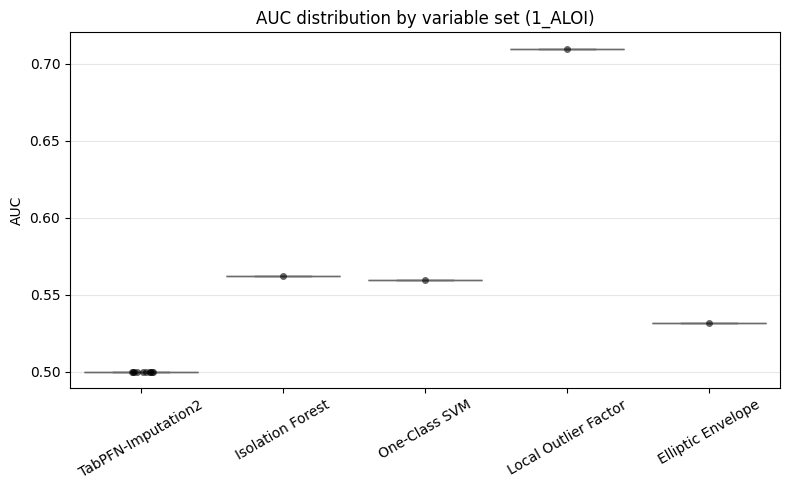

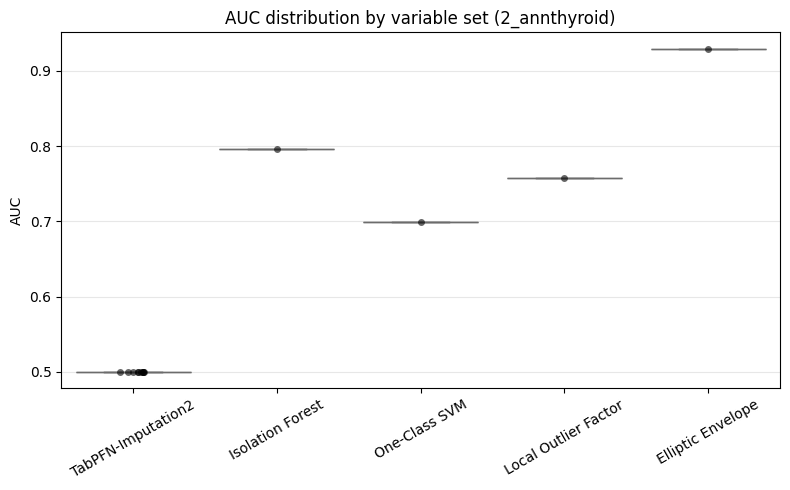

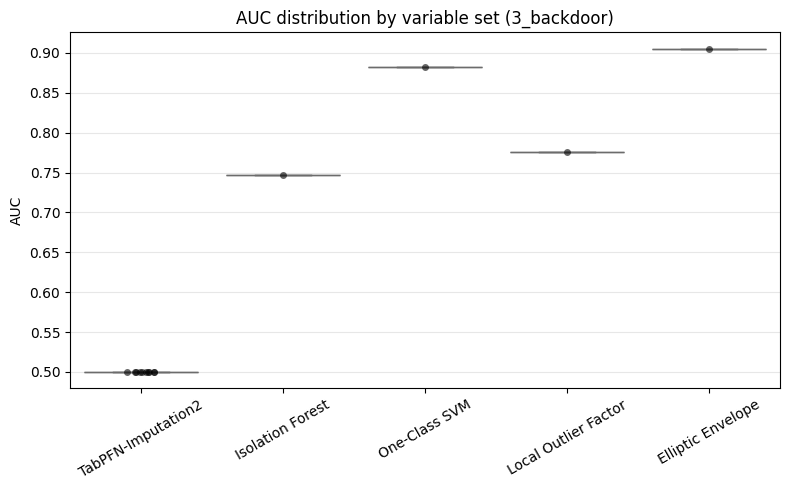

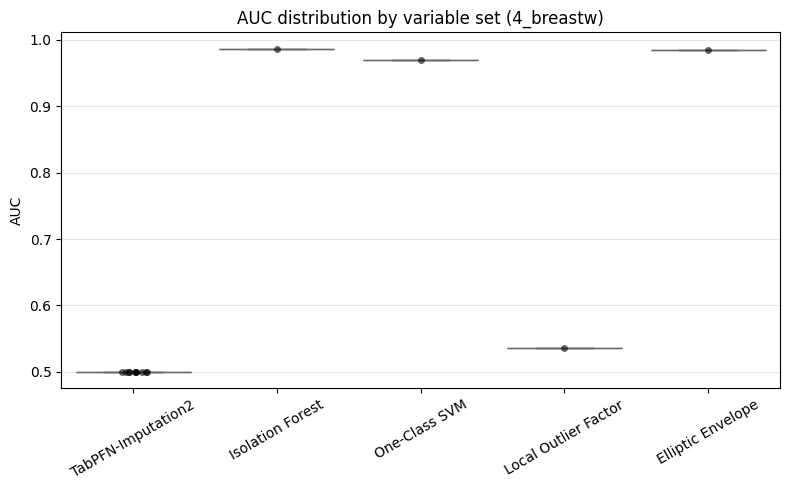

In [ ]:
# 같은 dataset에서 verset 끼리 차이
import matplotlib.pyplot as plt
import seaborn as sns

for dataset_name in results_df['dataset'].unique():
    df_d = results_df[results_df['dataset'] == dataset_name]

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df_d,
        x='method',
        y='auc'
    )
    sns.stripplot(
        data=df_d,
        x='method',
        y='auc',
        color='black',
        alpha=0.6,
        jitter=True
    )

    plt.title(f'AUC distribution by variable set ({dataset_name})')
    plt.ylabel('AUC')
    plt.xlabel('')
    plt.xticks(rotation=30)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


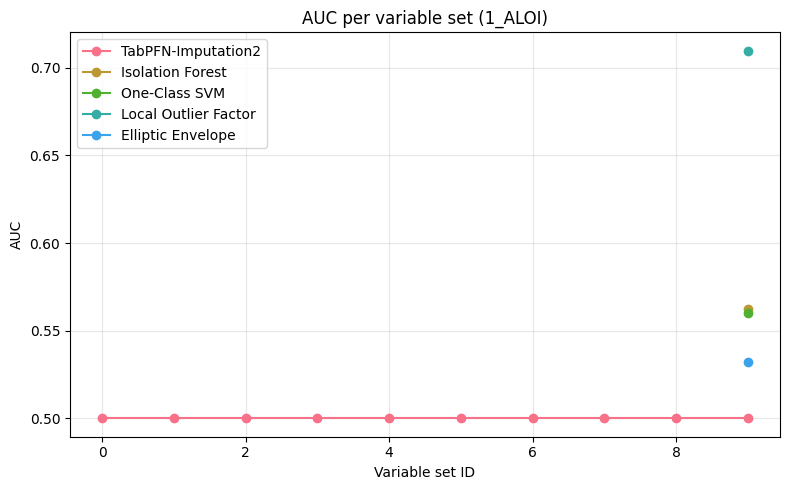

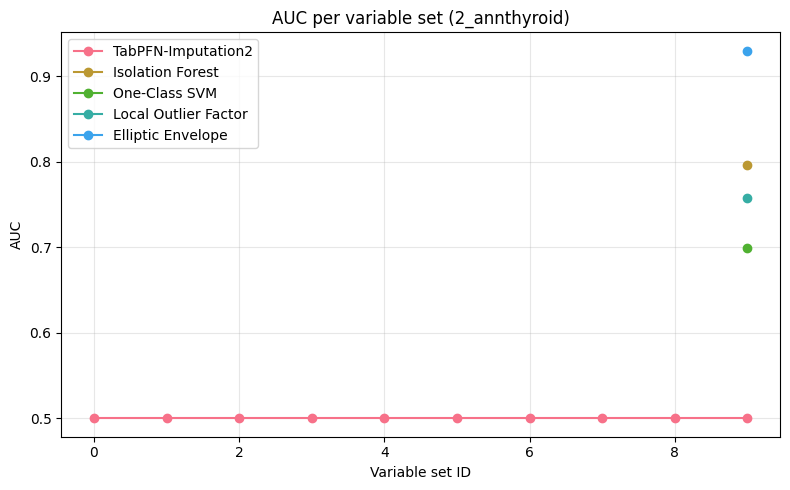

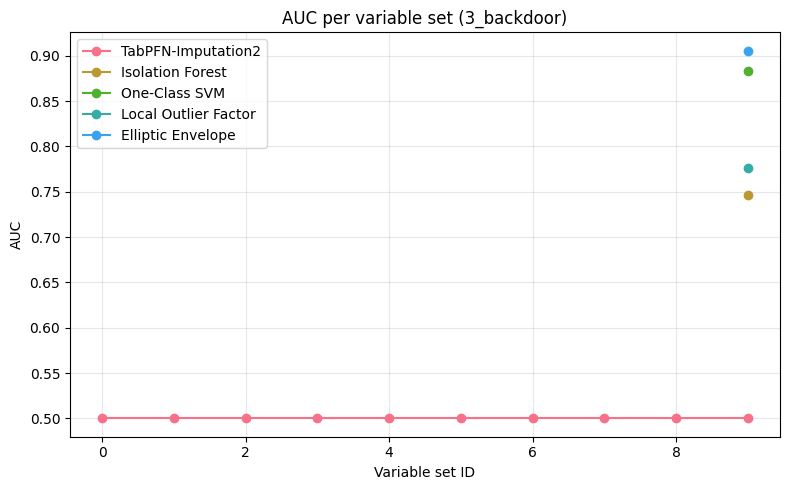

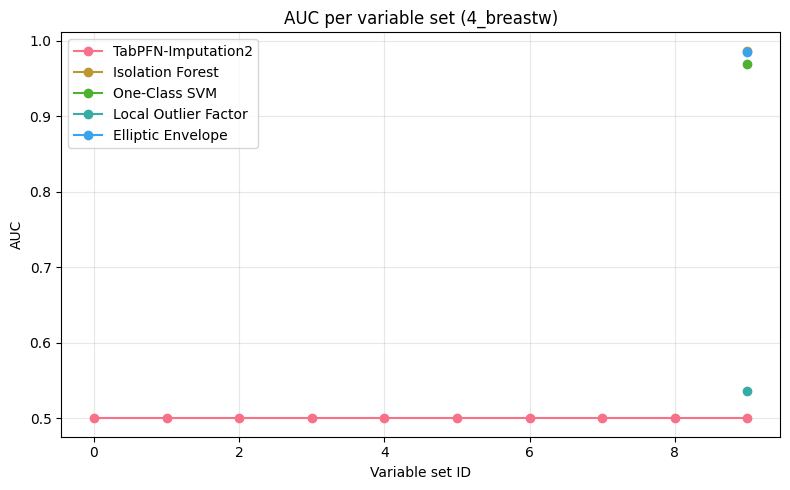

In [ ]:
# 같은 verset에서 method 비교
for dataset_name in results_df['dataset'].unique():
    df_d = results_df[results_df['dataset'] == dataset_name]

    plt.figure(figsize=(8, 5))
    for method in df_d['method'].unique():
        tmp = df_d[df_d['method'] == method].sort_values('varset')
        plt.plot(tmp['varset'], tmp['auc'], marker='o', label=method)

    plt.title(f'AUC per variable set ({dataset_name})')
    plt.xlabel('Variable set ID')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


KeyError: 'Column not found: accuracy'

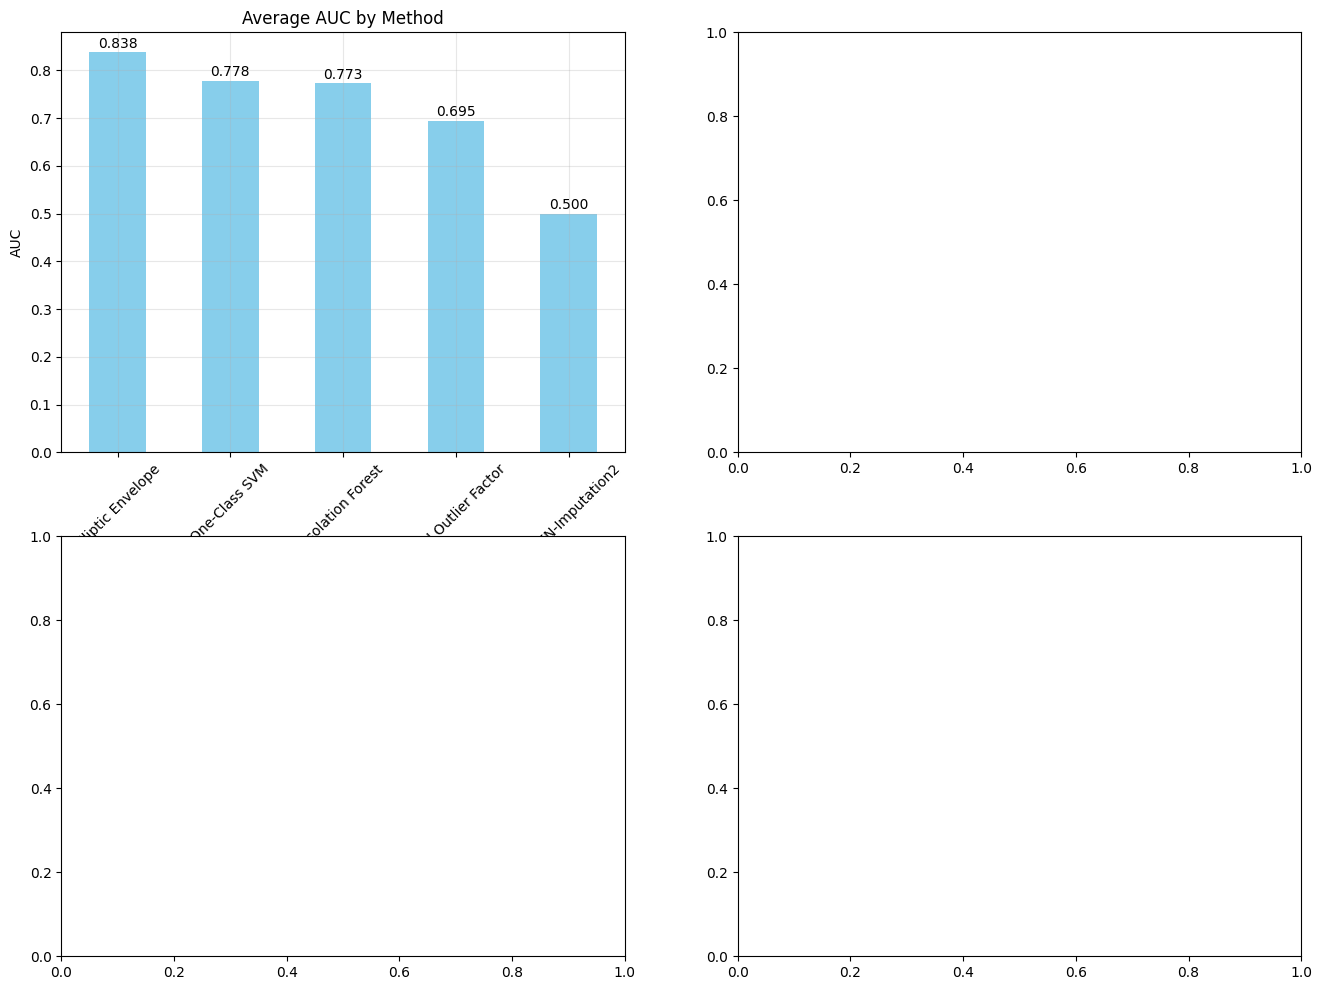

In [ ]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. AUC comparison by method
ax1 = axes[0, 0]
method_auc = results_df.groupby('method')['auc'].mean().sort_values(ascending=False)
method_auc.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Average AUC by Method')
ax1.set_ylabel('AUC')
ax1.set_xlabel('Method')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(method_auc.values):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center')

# 2. Accuracy comparison by method
ax2 = axes[0, 1]
method_acc = results_df.groupby('method')['accuracy'].mean().sort_values(ascending=False)
method_acc.plot(kind='bar', ax=ax2, color='lightcoral')
ax2.set_title('Average Accuracy by Method')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Method')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(method_acc.values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center')

# 3. AUC by dataset and method (heatmap)
ax3 = axes[1, 0]
pivot_auc = results_df.pivot_table(index='dataset', columns='method', values='auc', aggfunc='mean')
sns.heatmap(pivot_auc, annot=True, cmap='YlOrRd', ax=ax3, fmt='.3f')
ax3.set_title('AUC by Dataset and Method')
ax3.set_xlabel('Method')
ax3.set_ylabel('Dataset')

# 4. TabPFN performance by missing ratio
ax4 = axes[1, 1]
tabpfn_data = results_df[results_df['method'] == 'TabPFN Imputation']
if not tabpfn_data.empty:
    missing_ratio_perf = tabpfn_data.groupby('missing_ratio')[['auc', 'accuracy']].mean()
    missing_ratio_perf.plot(kind='line', marker='o', ax=ax4)
    ax4.set_title('TabPFN Performance by Missing Ratio')
    ax4.set_xlabel('Missing Ratio')
    ax4.set_ylabel('Performance')
    ax4.legend(['AUC', 'Accuracy'])
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No TabPFN data available', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


## 3. Classical Anomaly Detection Methods

In [ ]:
def get_classical_anomaly_scores(X):
    """Get anomaly scores from classical methods"""
    scores = {}
    
    # Standardize data for some methods
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    try:
        # 1. Isolation Forest
        iso_forest = IsolationForest(contamination='auto', random_state=42)
        iso_scores = iso_forest.fit(X).decision_function(X)
        scores['Isolation Forest'] = -iso_scores  # Convert to anomaly scores (higher = more anomalous)
    except Exception as e:
        print(f"Isolation Forest error: {e}")
        scores['Isolation Forest'] = np.zeros(len(X))
    
    try:
        # 2. One-Class SVM
        oc_svm = OneClassSVM(gamma='auto')
        svm_scores = oc_svm.fit(X_scaled).decision_function(X_scaled)
        scores['One-Class SVM'] = -svm_scores
    except Exception as e:
        print(f"One-Class SVM error: {e}")
        scores['One-Class SVM'] = np.zeros(len(X))
    
    try:
        # 3. Local Outlier Factor
        lof = LocalOutlierFactor(novelty=True)
        lof.fit(X_scaled)
        lof_scores = lof.decision_function(X_scaled)
        scores['Local Outlier Factor'] = -lof_scores
    except Exception as e:
        print(f"Local Outlier Factor error: {e}")
        scores['Local Outlier Factor'] = np.zeros(len(X))
    
    try:
        # 4. Elliptic Envelope
        ee = EllipticEnvelope(contamination=0.1, random_state=42)
        ee_scores = ee.fit(X_scaled).decision_function(X_scaled)
        scores['Elliptic Envelope'] = -ee_scores
    except Exception as e:
        print(f"Elliptic Envelope error: {e}")
        scores['Elliptic Envelope'] = np.zeros(len(X))
    
    return scores

## 4. 실험 수행: 모든 방법들 비교

In [ ]:
experiment_results = []
missing_ratios = [0.05, 0.1, 0.15]

print("Starting comprehensive anomaly detection comparison...")

for dataset_name in results.keys():
    print(f"\nProcessing {dataset_name}...")
    
    X = results[dataset_name]['X']
    y_true = results[dataset_name]['y']  # 0: normal, 1: anomaly
    
    # Skip datasets with too few anomalies
    if np.sum(y_true == 1) < 3:
        print(f"  Skipping {dataset_name}: too few anomalies ({np.sum(y_true == 1)})")
        continue
    
    # Classical methods (baseline)
    print("  Computing classical method scores...")
    classical_scores = get_classical_anomaly_scores(X)
    
    for method_name, scores in classical_scores.items():
        try:
            auc = roc_auc_score(y_true, scores)
            
            # Calculate accuracy using median threshold
            threshold = np.median(scores)
            y_pred = (scores > threshold).astype(int)
            accuracy = accuracy_score(y_true, y_pred)
            ap = average_precision_score(y_true, scores)
            
            experiment_results.append({
                'dataset': dataset_name,
                'method': method_name,
                'missing_ratio': None,
                'auc': auc,
                'accuracy': accuracy,
                'ap': ap,
                'n_samples': len(X),
                'n_anomalies': np.sum(y_true == 1)
            })
            
        except Exception as e:
            print(f"    Error evaluating {method_name}: {e}")
    
    # # TabPFN imputation method
    # for missing_ratio in missing_ratios:
    #     print(f"  Computing TabPFN imputation scores (missing ratio: {missing_ratio:.1%})...")
        
    #     try:
    #         tabpfn_scores = tabpfn_imputation_anomaly_scores(X, missing_ratio, n_trials=2)
            
    #         auc = roc_auc_score(y_true, tabpfn_scores)
            
    #         # Calculate accuracy using median threshold
    #         threshold = np.median(tabpfn_scores)
    #         y_pred = (tabpfn_scores > threshold).astype(int)
    #         accuracy = accuracy_score(y_true, y_pred)
    #         ap = average_precision_score(y_true, tabpfn_scores)
            
    #         experiment_results.append({
    #             'dataset': dataset_name,
    #             'method': 'TabPFN Imputation',
    #             'missing_ratio': missing_ratio,
    #             'auc': auc,
    #             'accuracy': accuracy,
    #             'ap': ap,
    #             'n_samples': len(X),
    #             'n_anomalies': np.sum(y_true == 1)
    #         })
            
    #         print(f"    TabPFN (missing {missing_ratio:.1%}): AUC={auc:.3f}, Accuracy={accuracy:.3f}")

            
    #     except Exception as e:
    #         print(f"    Error with TabPFN imputation (missing ratio {missing_ratio}): {e}")

    tabpfn_scores = tabpfn_xy_reconstruction_anomaly_scores(X, n_trials=3)
            
    auc = roc_auc_score(y_true, tabpfn_scores)
    
    # Calculate accuracy using median threshold
    threshold = np.median(tabpfn_scores)
    y_pred = (tabpfn_scores > threshold).astype(int)
    accuracy = accuracy_score(y_true, y_pred)
    ap = average_precision_score(y_true, tabpfn_scores)
    
    experiment_results.append({
        'dataset': dataset_name,
        'method': 'TabPFN Imputation2',
        'auc': auc,
        'accuracy': accuracy,
        'ap': ap,
        'n_samples': len(X),
        'n_anomalies': np.sum(y_true == 1)
    })
    
    print(f"    TabPFN (AUC={auc:.3f}, Accuracy={accuracy:.3f}")

# Convert to DataFrame
results_df = pd.DataFrame(experiment_results)
print("\nExperiment completed!")
print(f"Total experiments: {len(results_df)}")
print(results_df.head())

Starting comprehensive anomaly detection comparison...

Processing 1_ALOI...
  Computing classical method scores...
features split into [ 7 19 22 21 17  5 15 26 18 10  9  6 16  3] X and [ 0 23 20 12 11 14 25  2  4 24  1 13  8] Y
features split into [19  1  5 13  7 18 26 12 10  2 21  8 16  6] X and [25 11 24 23  9 14 17  4 20 15 22  0  3] Y
features split into [13 16  9  0 26 21  8 24 22  4 19  3 15 10] X and [12 20 11 25  2 18 17  5  1 14  6  7 23] Y
    TabPFN (AUC=0.547, Accuracy=0.505

Processing 2_annthyroid...
  Computing classical method scores...
features split into [3 2 5 4] X and [1 0] Y
features split into [5 1 4 2] X and [0 3] Y
features split into [3 0 2 5] X and [4 1] Y
    TabPFN (AUC=0.700, Accuracy=0.533

Processing 3_backdoor...
  Computing classical method scores...
features split into [ 37 186  92  20 150 154  96 135 177  98 128 145 126 192 149   7  66 118
  54  25  24 160 101 106  46 161  38  67  68  79   9 107  70 147 112  86
  75 191  33   3  29 170  89  80   8  5

## 5. 결과 분석 및 시각화

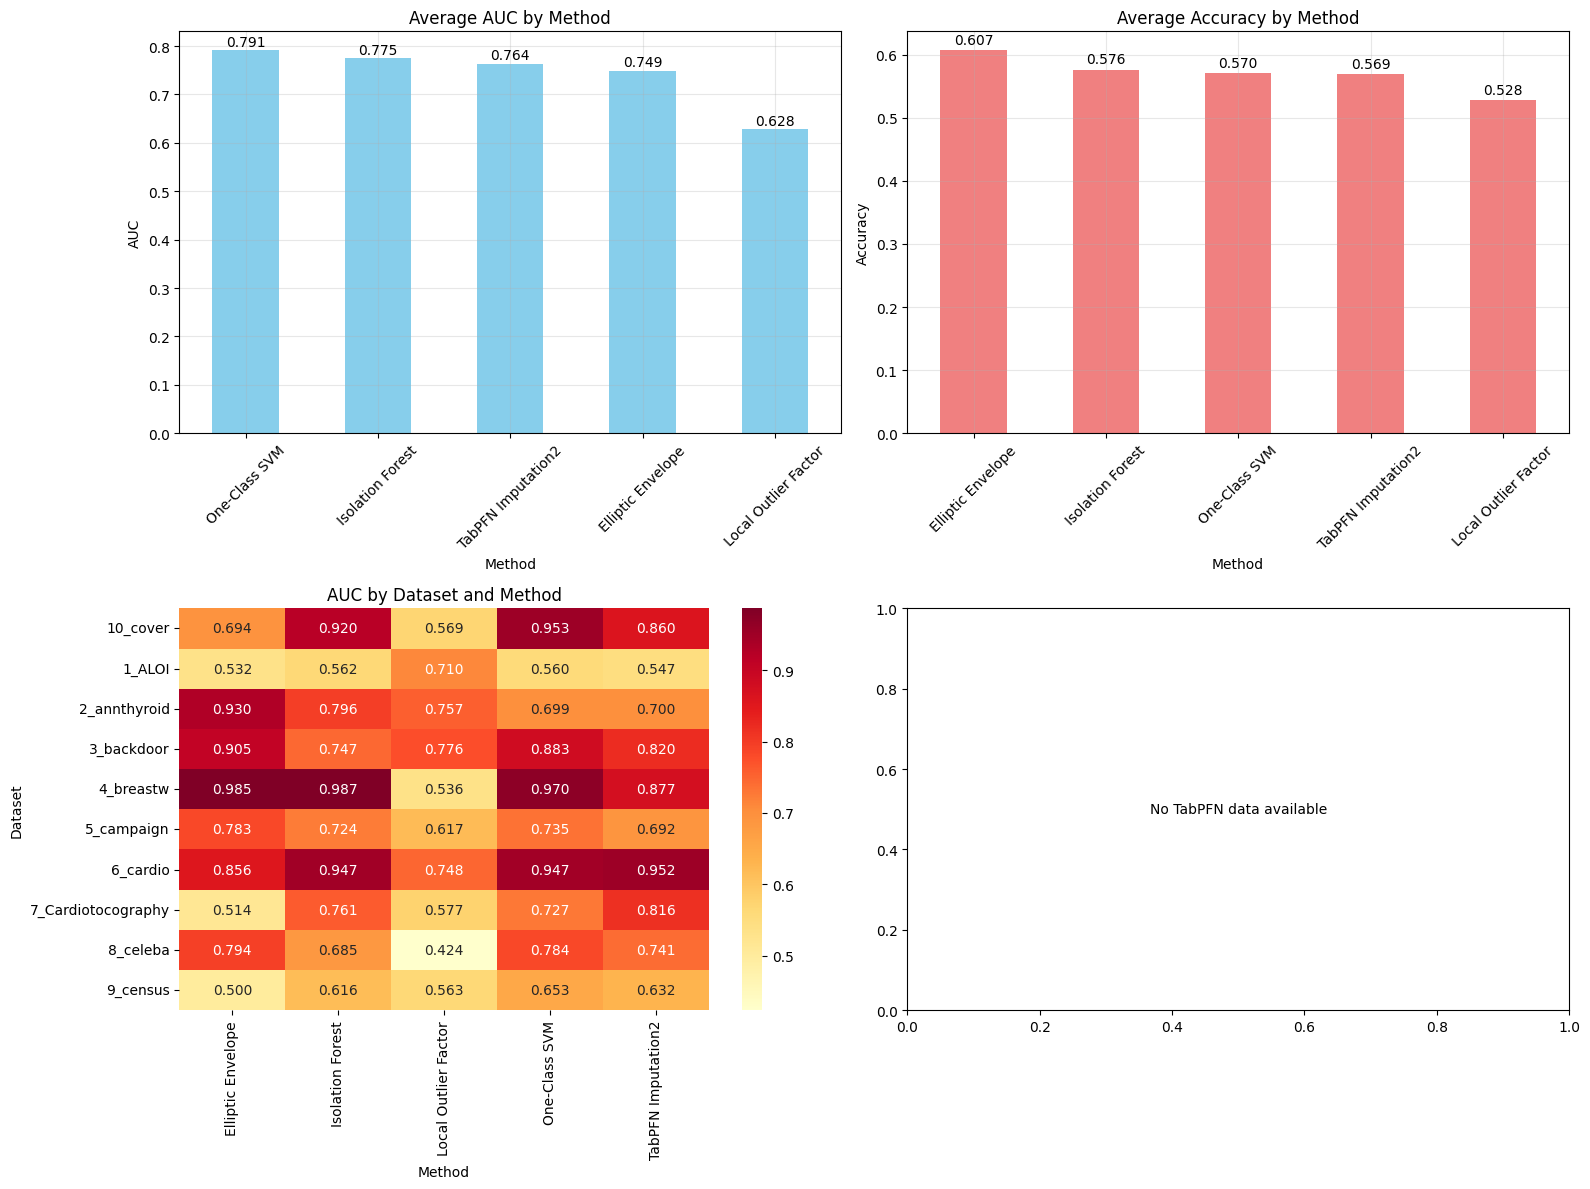

In [ ]:
# Performance comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. AUC comparison by method
ax1 = axes[0, 0]
method_auc = results_df.groupby('method')['auc'].mean().sort_values(ascending=False)
method_auc.plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Average AUC by Method')
ax1.set_ylabel('AUC')
ax1.set_xlabel('Method')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(method_auc.values):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center')

# 2. Accuracy comparison by method
ax2 = axes[0, 1]
method_acc = results_df.groupby('method')['accuracy'].mean().sort_values(ascending=False)
method_acc.plot(kind='bar', ax=ax2, color='lightcoral')
ax2.set_title('Average Accuracy by Method')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Method')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(method_acc.values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center')

# 3. AUC by dataset and method (heatmap)
ax3 = axes[1, 0]
pivot_auc = results_df.pivot_table(index='dataset', columns='method', values='auc', aggfunc='mean')
sns.heatmap(pivot_auc, annot=True, cmap='YlOrRd', ax=ax3, fmt='.3f')
ax3.set_title('AUC by Dataset and Method')
ax3.set_xlabel('Method')
ax3.set_ylabel('Dataset')

# 4. TabPFN performance by missing ratio
ax4 = axes[1, 1]
tabpfn_data = results_df[results_df['method'] == 'TabPFN Imputation']
if not tabpfn_data.empty:
    missing_ratio_perf = tabpfn_data.groupby('missing_ratio')[['auc', 'accuracy']].mean()
    missing_ratio_perf.plot(kind='line', marker='o', ax=ax4)
    ax4.set_title('TabPFN Performance by Missing Ratio')
    ax4.set_xlabel('Missing Ratio')
    ax4.set_ylabel('Performance')
    ax4.legend(['AUC', 'Accuracy'])
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No TabPFN data available', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


## 6. 통계적 분석

In [ ]:
# Statistical analysis
print("=== PERFORMANCE COMPARISON ANALYSIS ===")
print()

# Overall ranking
print("1. OVERALL RANKING (by AUC):")
print("-" * 40)
method_stats = results_df.groupby('method').agg({
    'auc': ['mean', 'std', 'count'],
    'accuracy': ['mean', 'std'],
    'ap': ['mean', 'std']
}).round(4)

# Flatten column names
method_stats.columns = ['_'.join(col).strip() for col in method_stats.columns]
method_stats = method_stats.sort_values('auc_mean', ascending=False)

for i, (method, row) in enumerate(method_stats.iterrows(), 1):
    print(f"{i}. {method}:")
    print(f"   AUC: {row['auc_mean']:.4f} ± {row['auc_std']:.4f} (n={int(row['auc_count'])})")
    print(f"   Accuracy: {row['accuracy_mean']:.4f} ± {row['accuracy_std']:.4f}")
    print(f"   AP: {row['ap_mean']:.4f} ± {row['ap_std']:.4f}")
    print()

# TabPFN vs Classical comparison
print("2. TabPFN vs CLASSICAL METHODS:")
print("-" * 40)

tabpfn_results = results_df[results_df['method'] == 'TabPFN Imputation']
classical_results = results_df[results_df['method'] != 'TabPFN Imputation']

if not tabpfn_results.empty and not classical_results.empty:
    tabpfn_auc = tabpfn_results['auc'].mean()
    classical_auc = classical_results.groupby('method')['auc'].mean().mean()
    
    tabpfn_acc = tabpfn_results['accuracy'].mean()
    classical_acc = classical_results.groupby('method')['accuracy'].mean().mean()
    
    print(f"TabPFN Imputation:")
    print(f"  Average AUC: {tabpfn_auc:.4f}")
    print(f"  Average Accuracy: {tabpfn_acc:.4f}")
    print()
    print(f"Classical Methods (average):")
    print(f"  Average AUC: {classical_auc:.4f}")
    print(f"  Average Accuracy: {classical_acc:.4f}")
    print()
    
    auc_improvement = (tabpfn_auc - classical_auc) / classical_auc * 100
    acc_improvement = (tabpfn_acc - classical_acc) / classical_acc * 100
    
    if tabpfn_auc > classical_auc:
        print(f"✅ TabPFN shows {auc_improvement:.1f}% better AUC than classical methods")
    else:
        print(f"❌ TabPFN shows {abs(auc_improvement):.1f}% worse AUC than classical methods")
        
    if tabpfn_acc > classical_acc:
        print(f"✅ TabPFN shows {acc_improvement:.1f}% better accuracy than classical methods")
    else:
        print(f"❌ TabPFN shows {abs(acc_improvement):.1f}% worse accuracy than classical methods")
else:
    print("Insufficient data for comparison")

print()
print("3. BEST PERFORMING METHOD PER DATASET:")
print("-" * 40)

for dataset in results_df['dataset'].unique():
    dataset_results = results_df[results_df['dataset'] == dataset]
    best_auc = dataset_results.loc[dataset_results['auc'].idxmax()]
    best_acc = dataset_results.loc[dataset_results['accuracy'].idxmax()]
    
    print(f"{dataset.upper()}:")
    print(f"  Best AUC: {best_auc['method']} ({best_auc['auc']:.4f})")
    print(f"  Best Accuracy: {best_acc['method']} ({best_acc['accuracy']:.4f})")
    print()

=== PERFORMANCE COMPARISON ANALYSIS ===

1. OVERALL RANKING (by AUC):
----------------------------------------
1. One-Class SVM:
   AUC: 0.7909 ± 0.1410 (n=10)
   Accuracy: 0.5704 ± 0.0989
   AP: 0.3304 ± 0.2905

2. Isolation Forest:
   AUC: 0.7745 ± 0.1406 (n=10)
   Accuracy: 0.5764 ± 0.1064
   AP: 0.2972 ± 0.3130

3. TabPFN Imputation2:
   AUC: 0.7636 ± 0.1236 (n=10)
   Accuracy: 0.5691 ± 0.0864
   AP: 0.3214 ± 0.2919

4. Elliptic Envelope:
   AUC: 0.7493 ± 0.1809 (n=10)
   Accuracy: 0.6067 ± 0.1572
   AP: 0.2930 ± 0.2952

5. Local Outlier Factor:
   AUC: 0.6278 ± 0.1156 (n=10)
   Accuracy: 0.5278 ± 0.0250
   AP: 0.1711 ± 0.1276

2. TabPFN vs CLASSICAL METHODS:
----------------------------------------
Insufficient data for comparison

3. BEST PERFORMING METHOD PER DATASET:
----------------------------------------
1_ALOI:
  Best AUC: Local Outlier Factor (0.7098)
  Best Accuracy: Local Outlier Factor (0.5174)

2_ANNTHYROID:
  Best AUC: Elliptic Envelope (0.9296)
  Best Accuracy: Ellip

## 7. ROC Curve 비교 (대표 데이터셋)

In [ ]:
# ROC curves for a representative dataset
representative_dataset = 'breastw'  # Choose dataset with good results

if representative_dataset in results.keys():
    X = results[representative_dataset]['X']
    y_true = results[representative_dataset]['y']
    
    plt.figure(figsize=(10, 8))
    
    # Classical methods
    classical_scores = get_classical_anomaly_scores(X)
    
    for method_name, scores in classical_scores.items():
        try:
            fpr, tpr, _ = roc_curve(y_true, scores)
            auc = roc_auc_score(y_true, scores)
            plt.plot(fpr, tpr, label=f'{method_name} (AUC={auc:.3f})', linewidth=2)
        except Exception as e:
            print(f"Error plotting {method_name}: {e}")
    
    # TabPFN imputation (best missing ratio)
    # try:
    #     tabpfn_scores = tabpfn_imputation_anomaly_scores(X, missing_ratio=0.1, n_trials=2)
    #     fpr, tpr, _ = roc_curve(y_true, tabpfn_scores)
    #     auc = roc_auc_score(y_true, tabpfn_scores)
    #     plt.plot(fpr, tpr, label=f'TabPFN Imputation (AUC={auc:.3f})', linewidth=3, linestyle='--')
    # except Exception as e:
    #     print(f"Error plotting TabPFN: {e}")

    try:
        tabpfn_scores2 = tabpfn_xy_reconstruction_anomaly_scores(X, n_trials=3)
        fpr, tpr, _ = roc_curve(y_true, tabpfn_scores2)
        auc = roc_auc_score(y_true, tabpfn_scores2)
        plt.plot(fpr, tpr, label=f'TabPFN Imputation2 (AUC={auc:.3f})', linewidth=3, linestyle='--')
    except Exception as e:
        print(f"Error plotting TabPFN: {e}")
    
    # Random classifier
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves Comparison ({representative_dataset.upper()} Dataset)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Dataset {representative_dataset} not available for ROC comparison")

Dataset breastw not available for ROC comparison


## 8. 결과 요약 및 저장

In [ ]:
# Summary table
print("=== FINAL SUMMARY ===\n")

# Create summary table
summary_table = results_df.groupby(['method']).agg({
    'auc': ['mean', 'std', 'max'],
    'accuracy': ['mean', 'std', 'max'],
    'ap': ['mean', 'std', 'max']
}).round(4)

summary_table.columns = ['AUC_mean', 'AUC_std', 'AUC_max', 'Acc_mean', 'Acc_std', 'Acc_max', 'AP_mean', 'AP_std', 'AP_max']
summary_table = summary_table.sort_values('AUC_mean', ascending=False)

print("Method\t\t\tAUC (mean±std)\tAccuracy (mean±std)\tAP (mean±std)")
print("-" * 80)

for method, row in summary_table.iterrows():
    method_short = method[:20] + "..." if len(method) > 20 else method
    print(f"{method_short:<20}\t{row['AUC_mean']:.3f}±{row['AUC_std']:.3f}\t{row['Acc_mean']:.3f}±{row['Acc_std']:.3f}\t\t{row['AP_mean']:.3f}±{row['AP_std']:.3f}")

# Best method overall
best_method = summary_table.index[0]
best_auc = summary_table.loc[best_method, 'AUC_mean']

print(f"\n🏆 BEST OVERALL METHOD: {best_method}")
print(f"   Average AUC: {best_auc:.4f}")

# Hypothesis conclusion
print("\n" + "=" * 80)
print("HYPOTHESIS EVALUATION:")
print("'TabPFN imputation 성능이 낮을수록 anomaly일 가능성이 높다'")
print("=" * 80)

tabpfn_results = results_df[results_df['method'] == 'TabPFN Imputation']
if not tabpfn_results.empty:
    avg_tabpfn_auc = tabpfn_results['auc'].mean()
    classical_methods = results_df[results_df['method'] != 'TabPFN Imputation']['method'].unique()
    
    better_than_count = 0
    for method in classical_methods:
        method_auc = results_df[results_df['method'] == method]['auc'].mean()
        if avg_tabpfn_auc > method_auc:
            better_than_count += 1
    
    if avg_tabpfn_auc > 0.7:  # Reasonable threshold
        print(f"✅ HYPOTHESIS SUPPORTED: TabPFN imputation achieves good anomaly detection performance")
        print(f"   Average AUC: {avg_tabpfn_auc:.4f}")
        print(f"   Outperforms {better_than_count}/{len(classical_methods)} classical methods")
    else:
        print(f"❌ HYPOTHESIS NEEDS REFINEMENT: TabPFN imputation shows moderate performance")
        print(f"   Average AUC: {avg_tabpfn_auc:.4f}")
else:
    print("⚠️ INSUFFICIENT TABPFN DATA: Cannot evaluate hypothesis")

# Save results
results_df.to_csv('anomaly_detection_comparison_results.csv', index=False)
print(f"\n📁 Results saved to 'anomaly_detection_comparison_results.csv'")
print(f"📁 Total experiments: {len(results_df)}")
print(f"📁 Datasets tested: {', '.join(results_df['dataset'].unique())}")

=== FINAL SUMMARY ===

Method			AUC (mean±std)	Accuracy (mean±std)	AP (mean±std)
--------------------------------------------------------------------------------
One-Class SVM       	0.791±0.141	0.570±0.099		0.330±0.290
Isolation Forest    	0.774±0.141	0.576±0.106		0.297±0.313
TabPFN Imputation2  	0.764±0.124	0.569±0.086		0.321±0.292
Elliptic Envelope   	0.749±0.181	0.607±0.157		0.293±0.295
Local Outlier Factor	0.628±0.116	0.528±0.025		0.171±0.128

🏆 BEST OVERALL METHOD: One-Class SVM
   Average AUC: 0.7909

HYPOTHESIS EVALUATION:
'TabPFN imputation 성능이 낮을수록 anomaly일 가능성이 높다'
⚠️ INSUFFICIENT TABPFN DATA: Cannot evaluate hypothesis

📁 Results saved to 'anomaly_detection_comparison_results.csv'
📁 Total experiments: 50
📁 Datasets tested: 1_ALOI, 2_annthyroid, 3_backdoor, 4_breastw, 5_campaign, 6_cardio, 7_Cardiotocography, 8_celeba, 9_census, 10_cover
